In [2]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
from lab_utils_common import plot_data, sigmoid, draw_vthresh
plt.style.use('./deeplearning.mplstyle')

In [8]:
def sigmoid2(z):
    """
    Compute the sigmoid of z

    Parameters
    ----------
    z : array_like
        A scalar or numpy array of any size.

    Returns
    -------
     g : array_like
         sigmoid(z)
    """
    z = np.clip( z, -500, 500 )           # protect against overflow
    g = 1.0/(1.0+np.exp2(-z))

    return g


为什么选用 e 作为 sigmoid 的底数?

> - 梯度计算方便：使用 e 作为底数时，sigmoid 函数的导数可以用 sigmoid 函数本身来表示
> - 在神经网络中，e 作为底数的 sigmoid 函数在信息传递和激活方面具有更好的表现，更适合作为激活函数使用。


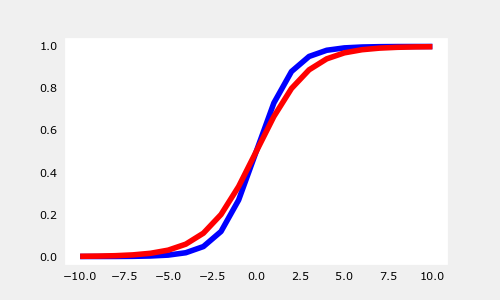

In [10]:
z = np.arange(-10, 11)

fig, ax = plt.subplots(1, figsize=(5,3))
ax.plot(z, sigmoid(z), c='b')
ax.plot(z, sigmoid2(z), c='r')

在

$g(z) = \frac{1}{1+e^{-z}}\tag{2}$

中, 不同的 z 函数, 对于 sigmoid 函数的形状有哪些影响?

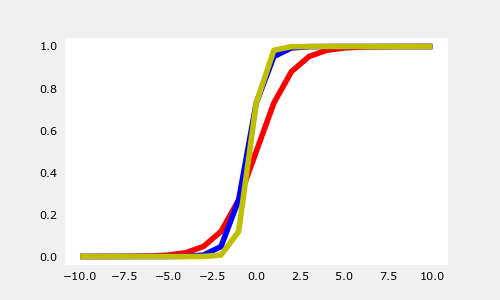

In [29]:
z = np.arange(-10, 11)

fig, ax = plt.subplots(1, figsize=(5,3))
ax.plot(z, sigmoid(z), c='r')
ax.plot(z, sigmoid(2*z+1), c='b')
ax.plot(z, sigmoid(3*z+1), c='y')

### Logistic loss function

This is defined: 
* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ is the cost for a single data point, which is:

\begin{equation}
  loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = \begin{cases}
    - \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=1$}\\
    - \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) & \text{if $y^{(i)}=0$}
  \end{cases}
\end{equation}


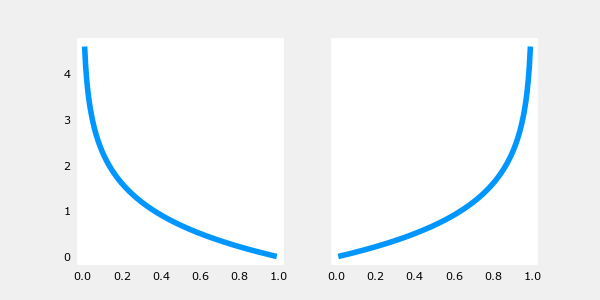

In [4]:
x = np.linspace(0.01, 1-0.01, 200)
fig, ax = plt.subplots(1, 2, figsize=(6, 3), sharey=True)
ax[0].plot(x, -np.log(x))
ax[1].plot(x, -np.log(1-x))

### By Scikit-Learn

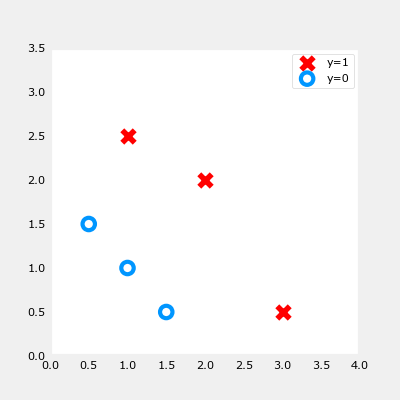

In [14]:
import numpy as np

X = np.array([[0.5, 1.5], [1, 1], [1.5, 0.5], [3, 0.5], [2, 2], [1, 2.5]])
y = np.array([0, 0, 0, 1, 1, 1])

from lab_utils_common import  dlc, plot_data, plt_tumor_data, sigmoid, compute_cost_logistic
from plt_quad_logistic import plt_quad_logistic, plt_prob
fig, ax = plt.subplots(1,1,figsize=(4,4))
ax.axis([0, 4, 0, 3.5])
plot_data(X, y, ax)

In [22]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=10000, verbose=1)
lr_model.fit(X, y)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  4.15888D+00    |proj g|=  1.50000D+00


 This problem is unconstrained.


LogisticRegression(max_iter=10000, verbose=1)


           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      7     10      1     0     0   5.398D-05   3.122D+00
  F =   3.1218096467453789     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            


In [18]:
print(f"Prediction on training set: {lr_model.predict(X)}")
print(f"Accuracy on training set: {lr_model.score(X, y)}")

Prediction on training set: [0 0 0 1 1 1]
Accuracy on training set: 1.0
